In [2]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import flet as ft
from scipy.interpolate import PchipInterpolator
import numpy as np

In [65]:
jgb_rates_df = pd.read_csv('src/jgb_rates.csv',sep='\t', encoding='utf-8', header=None, names=["year", "rate"],).set_index("year")
val_array = jgb_rates_df.iloc[0:,0].to_numpy()
val_array

array([0.22436784, 0.38146498, 0.39984089, 0.47594691, 0.56244763,
       0.95360039, 1.4071004 , 1.73773584, 1.93187733, 2.06490854])

In [67]:
col_series = jgb_rates_df.T.columns.to_series().apply(lambda x: x[:-1])
print(col_series)
col_array = col_series.values.astype(int)
print(col_array,val_array)

year
1年      1
2年      2
3年      3
4年      4
5年      5
10年    10
15年    15
20年    20
25年    25
30年    30
Name: year, dtype: object
[ 1  2  3  4  5 10 15 20 25 30] [0.22436784 0.38146498 0.39984089 0.47594691 0.56244763 0.95360039
 1.4071004  1.73773584 1.93187733 2.06490854]


In [47]:
pchip = PchipInterpolator(col_array, val_array)

[[0.95360039 1.04228949 1.13700161 1.23271918 1.32442463 1.4071004
  1.48261067 1.55507053 1.6228388  1.6842743  1.73773584 1.78418802
  1.82614504 1.86429012 1.89930648 1.93187733 1.96264187 1.99160121
  2.0184814  2.04300849 2.06490854]]


<Axes: >

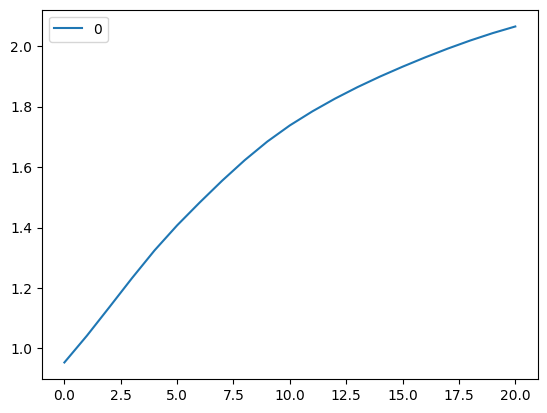

In [64]:
target_number = int(16)
target_numbers = [10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30]
target = [target_numbers]
result = pchip(target)
print(result)
result_series = pd.DataFrame(result)
result_series.T.plot()

In [2]:
engine = create_engine('sqlite:///VFM.db', echo=False, connect_args={'check_same_thread': False})

In [3]:
conn = sqlite3.connect('VFM.db')
c = conn.cursor()

In [4]:
c.execute("SELECT name FROM sqlite_master WHERE type='table';")

In [5]:
c.fetchall()

[('PSC_res_table',),
 ('PSC_pv_res_table',),
 ('LCC_res_table',),
 ('LCC_pv_res_table',),
 ('SPC_res_table',),
 ('SPC_check_res_table',),
 ('Risk_res_table',),
 ('VFM_res_table',),
 ('PIRR_res_table',),
 ('res_summ_res_table',),
 ('final_inputs_table',),
 ('final_inputs_res_table',),
 ('PSC_table',),
 ('LCC_table',),
 ('SPC_table',),
 ('Risk_table',),
 ('VFM_table',),
 ('PSC_pv_table',),
 ('LCC_pv_table',),
 ('PIRR_table',),
 ('SPC_check_table',)]

In [24]:
res_summ_df = pd.read_sql_table('res_summ_res_table', engine)
print(res_summ_df)
dtime = '2026-04-17 00:14:13+09:00'
res_summ_df.query('datetime==@dtime').drop(['datetime','user_id','calc_id'],axis=1).iloc[0].rename(
            {
            "VFM_percent": "VFM(%)",
            "PSC_present_value": "PSC現在価値総額",
            "LCC_present_value": "LCC現在価値総額",
            "PIRR": "プロジェクトの内部収益率(%)",
            "kariire_kinri": "借入コスト(%)",
            "discount_rate": "割引率(%)",
            "SPC_payment_cash":"SPCのキャッシュ水準",
            "mgmt_type": "施設管理者種別",
            "proj_ctgry": "事業類型",
            "proj_type": "事業方式",
            "proj_years": "事業期間",
            "const_years": "施設整備期間",
            },
            ).to_dict()

    VFM_percent  PSC_present_value  LCC_present_value      PIRR  \
0      1.094708       -7073.712457       -6996.275966  2.571708   
1     -0.183129       -7208.728483       -7221.929725  3.086324   
2      8.511515       -4376.224214       -4003.741252  2.110399   
3     14.004361       -3414.212355       -2936.073747  0.274704   
4      0.736689       -6632.062755       -6583.205062 -0.801441   
5      5.931204      -10514.785004       -9891.131661  2.638548   
6      8.209789       -7960.248096       -7306.728521  2.433598   
7      9.468518       -6298.069320       -5701.735494  1.263641   
8      5.034760       -4733.615230       -4495.289044  2.580430   
9      6.313952       -8680.460399       -8132.380321  2.172350   
10     6.152672       -9253.421276       -8684.088631  2.979593   
11     7.110722       -4079.406355       -3789.331092  1.783512   

   SPC_payment_cash mgmt_type proj_ctgry proj_type  const_years  proj_years  \
0           返済資金は十分       市町村    サービス購入型       BT

{'VFM(%)': 1.0947079270004882,
 'PSC現在価値総額': -7073.712457,
 'LCC現在価値総額': -6996.275966,
 'プロジェクトの内部収益率(%)': 2.571707779308987,
 'SPCのキャッシュ水準': '返済資金は十分',
 '施設管理者種別': '市町村',
 '事業類型': 'サービス購入型',
 '事業方式': 'BTO',
 '施設整備期間': 2,
 '事業期間': 14,
 '割引率(%)': 0.030447,
 '借入コスト(%)': 2.407,
 'Kappu_kinri': 3.4071,
 'kappu_kinri_spread': 1.0,
 'SPC_fee': 30.0}

In [ ]:
#res_summ_df = c.sql('select * from res_summ_df_res_table').df()
grd_df_exp = res_summ_df.groupby('datetime').apply(lambda x: x.head(1), include_groups=False)
#print(grd_df_exp)
grd_df_exp_ri = grd_df_exp.reset_index().drop('level_1', axis=1)
grd_df_exp_ri_r = grd_df_exp_ri.sort_values('datetime', ascending=False)
#print(grd_df_exp_ri_r)
grd_df_exp_ri2 = grd_df_exp_ri_r[[
            'datetime',
            'VFM_percent',
            'PSC_present_value',
            'LCC_present_value',
            'PIRR',
            'kariire_kinri',
            'discount_rate',
            'SPC_payment_cash',
            'mgmt_type',
            'proj_ctgry',
            'proj_type',
            'proj_years',
            'const_years'
            ]]
        
res_summ_list = grd_df_exp_ri2.rename(
            #columns={
            #"datetime": "算定日時",
            #"VFM_percent": "VFM(%)",
            #"PSC_present_value": "PSC現在価値総額",
            #"LCC_present_value": "LCC現在価値総額",
            #"PIRR": "プロジェクトの内部収益率(%)",
            #"kariire_kinri": "借入コスト(%)",
            #"discount_rate": "割引率(%)",
            #"SPC_payment_cash":"SPCのキャッシュ水準",
            #"mgmt_type": "施設管理者種別",
            #"proj_ctgry": "事業類型",
            #"proj_type": "事業方式",
            #"proj_years": "事業期間",
            #"const_years": "施設整備期間",
            #},
                index={0: 0},
            )
print(res_summ_list)
index_list = res_summ_list.index.tolist()
col_list = res_summ_list.columns.tolist()
index_list.reverse()
print(index_list)
print(col_list)

In [8]:
for row in res_summ_list.itertuples():
    #print(row)
    #print(type(row))
    row_dic = row._asdict()
    print(row_dic.keys())
    #row = pd.DataFrame(row).drop(0, axis=0)
    row = pd.DataFrame(row_dic, index=[0])
    dtime = row['datetime'].iloc[0]
    print(dtime)
    row = row.rename(
            columns={
            "datetime": "算定日時",
            "VFM_percent": "VFM(%)",
            "PSC_present_value": "PSC現在価値総額",
            "LCC_present_value": "LCC現在価値総額",
            "PIRR": "プロジェクトの内部収益率(%)",
            "kariire_kinri": "借入コスト(%)",
            "discount_rate": "割引率(%)",
            "SPC_payment_cash":"SPCのキャッシュ水準",
            "mgmt_type": "施設管理者種別",
            "proj_ctgry": "事業類型",
            "proj_type": "事業方式",
            "proj_years": "事業期間",
            "const_years": "施設整備期間",
            },

    )
    row = row.T.reset_index()
    row = row.rename(columns={"index":"項目名",0:"値",}).drop(0,axis=0)
    print(row)
    #df = DataFrame(row)
    #dr = df.datarows
    #dtime = dr[0].cells[0].content.value
    #for j in range(len(dr)):
    #    dr[j].data = dtime
    #    for i in dr[j]:
    #        i.data = dtime                
    #        i.color=ft.Colors.AMBER_50
    #        i.selected=False
    #        i.on_long_press=self.send_mess
    #        i.on_select_changed=self.send_mess

#df_t  = df.tranpose().reset_index()
#table = df.datatable


dict_keys(['Index', 'datetime', 'VFM_percent', 'PSC_present_value', 'LCC_present_value', 'PIRR', 'kariire_kinri', 'discount_rate', 'SPC_payment_cash', 'mgmt_type', 'proj_ctgry', 'proj_type', 'proj_years', 'const_years'])
2025-01-14 23:27:18
                項目名                    値
1              算定日時  2025-01-14 23:27:18
2            VFM(%)            12.609001
3         PSC現在価値総額         -3459.702902
4         LCC現在価値総額         -3023.468939
5   プロジェクトの内部収益率(%)             2.414597
6          借入コスト(%)                  2.6
7            割引率(%)             0.033625
8       SPCのキャッシュ水準              返済資金は十分
9           施設管理者種別                  市町村
10             事業類型              サービス購入型
11             事業方式           BTO/DBO/RO
12             事業期間                   19
13           施設整備期間                    2
dict_keys(['Index', 'datetime', 'VFM_percent', 'PSC_present_value', 'LCC_present_value', 'PIRR', 'kariire_kinri', 'discount_rate', 'SPC_payment_cash', 'mgmt_type', 'proj_ctgry', 'proj_t

In [11]:
pd.read_sql_query('select * from VFM_res_table', engine)

,VFM,VFM_percent,datetime,user_id,calc_id
0,-446.588491,14.050577,2025-01-12 15:41:24,01JHCKXVT6DY9QAR2ZB2J2CKRA,02ymqQxPE7UwFPGTE1MgrX
1,-451.449720,14.610414,2025-01-12 16:11:44,01JHCNND357DTJ6FTYGT6K26EM,02ymrB6ofEdnZoBWl6h9bR
2,-443.090538,13.549578,2025-01-12 16:21:48,01JHCP7V946C0J4N6WKCKV5RPS,02ymrQR0tOAgg8ig0pdmyj
3,-443.090538,13.549578,2025-01-12 16:37:33,01JHCQ4PHBABHT6NCJWB9M864Y,02ymroPS0qHim77E0ogCnG


In [17]:
dic = {'a': 100}
list(dic.keys())[0]

'a'

In [2]:
page = ft.Page

In [5]:
page.session.store.get_keys()

AttributeError: 'property' object has no attribute 'store'